In [16]:
import os
import operator
from typing import TypedDict, Annotated, List, Dict, Any, Literal
from dotenv import load_dotenv

load_dotenv()

True

In [17]:
# 1. Structured Data Models
class Claim(TypedDict):
    claim_id: str # e.g., "FIN-001"
    claim: str
    evidence: str
    source: str

class VerifiedClaim(TypedDict):
    domain: str 
    claim_data: Claim
    verification_status: Literal["Verified", "Unverified", "Contradicted"]
    reasoning: str 

# 2. The Subgraph State (Domain Expert)
class ResearchState(TypedDict):
    topic: str
    search_queries: List[str]
    raw_docs: Annotated[List[Dict[str, Any]], operator.add] 
    extracted_claims: Annotated[List[Claim], operator.add] 
    domain_verified_claims: Annotated[List[VerifiedClaim], operator.add]

# 3. The Global State (Orchestrator & Synthesizer)
class BaseeraState(TypedDict):
    company_name: str
    research_goal: str
    
    # E.g., {"financial": ["2025 revenue"], "market": ["competitors"]}
    research_plan: Dict[str, List[str]] 
    
    # LangGraph will automatically concatenate the lists returned by subgraphs
    all_verified_claims: Annotated[List[VerifiedClaim], operator.add]
    
    # The Cross-Domain Synthesizer populates this after facts are verified
    cross_domain_analysis: str
    
    human_feedback: str
    final_report: str
        
print("Baseera Strict Validation Architecture initialized successfully!")

Baseera Strict Validation Architecture initialized successfully!


In [18]:
import os
from langchain_core.tools import tool
from tavily import TavilyClient
from youtube_transcript_api import YouTubeTranscriptApi
from youtube_transcript_api.formatters import TextFormatter

In [19]:
# 1. Initialize Tavily Client
tavily_client = TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))

@tool
def tavily_search(query: str, max_results: int = 3) -> str:
    """
    Search the web for real-time market data, company news, and reports.
    Always prioritize authoritative sources (e.g., Reuters, Bloomberg, official reports).
    """
    try:
        response = tavily_client.search(
            query=query, 
            search_depth="advanced", 
            max_results=max_results,
            include_raw_content=True
        )
        
        results_str = ""
        for result in response.get("results", []):
            title = result.get("title") or "No Title"
            url = result.get("url") or "No URL"
            # Use 'or' fallback to protect against explicit None values
            content = result.get("raw_content") or result.get("content") or ""
            
            results_str += f"Source: {title} ({url})\nContent: {content[:2000]}\n\n"
            
        return results_str if results_str.strip() else "No relevant results found."
    except Exception as e:
        return f"Error executing search: {str(e)}"

@tool
def extract_youtube_transcript(video_id: str) -> str:
    """
    Extracts the text transcript from a YouTube video (e.g., an executive interview or news report).
    Input must be the exact 11-character video ID, not the full URL.
    """
    try:
        # Prioritize English, fallback to Arabic
        transcript = YouTubeTranscriptApi.get_transcript(video_id, languages=['en', 'ar'])
        formatter = TextFormatter()
        formatted_text = formatter.format_transcript(transcript)
        
        return formatted_text[:3000] # Truncate to save tokens
    except Exception as e:
        return f"Error extracting video transcript: {str(e)}"

# We group them in a list to easily pass them to our agents later
baseera_tools = [tavily_search, extract_youtube_transcript]

print("Baseera OSINT Toolbelt successfully loaded!")

Baseera OSINT Toolbelt successfully loaded!


Now we have our State schema and our tools. The next step is building the actual LangGraph Nodes—the Python functions that use the LLM to transition the graph from one state to the next.

#1 The Planner Node
The Planner is the entry point of the global BaseeraState. It receives the company_name and research_goal, and it outputs a JSON object (the research_plan). It does no searching itself; it acts purely as the Lead Analyst delegating tasks.

In [20]:
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.1)

# 1. Define a strict object for each domain
class ResearchDomain(BaseModel):
    domain: str = Field(description="The name of the research domain (e.g., 'financial', 'legal', 'market', 'cybersecurity')")
    queries: List[str] = Field(description="List of specific search queries for this domain")

# 2. The main plan is a list of these objects
class ResearchPlan(BaseModel):
    plan: List[ResearchDomain]

def planner_node(state: BaseeraState) -> Dict:
    company = state.get("company_name", "")
    goal = state.get("research_goal", "")
    
    prompt = f"""
    You are the Lead Analyst at Bain & Company. 
    Your client needs a strategic due diligence report on: {company}.
    The specific goal of this research is: {goal}.
    
    Create a highly targeted research plan. Break the research down into 3-4 distinct domains.
    For each domain, write 2-3 highly specific search queries that a junior analyst should run.
    Do NOT write generic queries like 'company overview'. Be specific to the goal.
    """
    
    structured_llm = llm.with_structured_output(ResearchPlan)
    
    print(f"🤖 Planner: Generating research strategy for {company}...")
    result = structured_llm.invoke(prompt)
    
    # 3. Convert the strict List back into our dynamic Dictionary for the State!
    formatted_plan_dict = {item.domain: item.queries for item in result.plan}
    
    return {"research_plan": formatted_plan_dict}

print("Planner node defined successfully.")

Planner node defined successfully.


In [21]:
# 1. Create a mock State with our company and goal
mock_state = BaseeraState(
    company_name="STC (Saudi Telecom Company)",
    research_goal="Assess their diversification strategy away from traditional telecom into digital services (fintech, cloud, IoT) to evaluate long-term revenue resilience.",
    research_plan={},
    all_verified_claims=[],
    cross_domain_analysis="",
    human_feedback="",
    final_report=""
)

# 2. Run the Planner Node
print(f"Executing Planner Node for: {mock_state['company_name']}...\n")
new_state_update = planner_node(mock_state)

# 3. Print the resulting Research Plan
import json
print("🎯 Generated Research Plan:")
print(json.dumps(new_state_update["research_plan"], indent=2))

Executing Planner Node for: STC (Saudi Telecom Company)...

🤖 Planner: Generating research strategy for STC (Saudi Telecom Company)...
🎯 Generated Research Plan:
{
  "Market Analysis of Digital Services": [
    "STC digital services market share in fintech 2023",
    "growth trends in STC cloud services revenue 2023",
    "impact of IoT on STC's revenue diversification strategy"
  ],
  "Competitive Landscape": [
    "key competitors of STC in fintech and their market strategies",
    "comparison of STC's digital service offerings with competitors",
    "SWOT analysis of STC's diversification into digital services"
  ],
  "Financial Performance and Projections": [
    "STC revenue breakdown by segment: telecom vs digital services 2023",
    "financial forecasts for STC's digital services over the next 5 years",
    "historical revenue growth rates for STC's fintech and cloud services"
  ],
  "Regulatory and Economic Environment": [
    "impact of Saudi regulations on STC's digital servi

/Users/ranaalngashy/Documents/multimodal-osint-analyst/.venv/lib/python3.9/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=ResearchPlan(plan=[Resear...ion in Saudi Arabia'])]), input_type=ResearchPlan])
  return self.__pydantic_serializer__.to_python(


Building the Domain Expert (The Research Subgraph)
Now we build the actual engine that does the heavy lifting: the researcher_node. This function will take one of those topics (like "Financial Performance Analysis") and its queries, use our Tavily/YouTube tools to search the web, and extract claims into our strict Pydantic schema.

In [22]:
from langchain_core.messages import HumanMessage, SystemMessage

# 1. We must define the Pydantic schema for the claims the LLM will extract
class ClaimExtraction(BaseModel):
    claim_id: str = Field(description="A unique ID for this claim (e.g., FIN-001)")
    claim: str = Field(description="The factual claim extracted from the source")
    evidence: str = Field(description="The exact quote or reasoning from the source")
    source: str = Field(description="The name or URL of the source document")

class ExtractedClaimsList(BaseModel):
    claims: List[ClaimExtraction]

# Initialize the LLM and bind our tools to it
llm_with_tools = llm.bind_tools(baseera_tools)

def researcher_node(state: ResearchState) -> Dict:
    """
    The Domain Expert. Executes searches for a specific topic, reads the raw text, 
    and extracts verifiable claims into a strict JSON array.
    """
    topic = state.get("topic", "")
    queries = state.get("search_queries", [])
    
    print(f"🕵️‍♂️ Subgraph [{topic}]: Starting research...")
    
    # 1. Execute the tools to gather raw data
    raw_data_compiled = []
    for q in queries:
        print(f"   -> Searching: {q}")
        # We manually call our Tavily tool function for each query
        tool_result = tavily_search.invoke({"query": q})
        raw_data_compiled.append({"query": q, "content": tool_result})
        
    # 2. Extract structured claims using the LLM
    print(f"🧠 Subgraph [{topic}]: Extracting claims from raw text...")
    
    # Dump the heavy raw text into a string for the prompt
    context_str = "\n".join([f"Query: {r['query']}\nResult: {r['content'][:1500]}" for r in raw_data_compiled])
    
    prompt = f"""
    You are an expert Due Diligence Analyst specializing in the '{topic}' domain.
    Review the following raw search data and extract the most critical factual claims.
    
    Raw Data:
    {context_str}
    
    Extract 2 to 4 major claims.
    """
    
    structured_extractor = llm.with_structured_output(ExtractedClaimsList)
    result = structured_extractor.invoke(prompt)
    
    # Format the Pydantic output back into the standard dictionaries our State expects
    formatted_claims = [
        {"claim_id": c.claim_id, "claim": c.claim, "evidence": c.evidence, "source": c.source}
        for c in result.claims
    ]
    
    # Return updates to the Subgraph State
    return {
        "raw_docs": raw_data_compiled, 
        "extracted_claims": formatted_claims
    }

print("Researcher Node (Subgraph entry point) defined successfully.")

Researcher Node (Subgraph entry point) defined successfully.


In [23]:
import json

# 1. Create a mock ResearchState for the Financial Domain
mock_financial_state = {
    "topic": "Financial Performance Analysis",
    "search_queries": [
        "STC revenue breakdown by segment for digital services",
        "historical financial performance of STC's fintech and cloud services",
        "impact of IoT services on STC's overall revenue growth"
    ],
    "raw_docs": [],
    "extracted_claims": [],
    "domain_verified_claims": [] # We haven't built the fact checker yet
}

# 2. Execute the Researcher Node
print("Starting Domain Expert Node (This will take 10-15 seconds to scrape the web)...")
financial_result = researcher_node(mock_financial_state)

# 3. Print the Extracted Claims
print("\n✅ Extracted Claims:")
print(json.dumps(financial_result["extracted_claims"], indent=2))

Starting Domain Expert Node (This will take 10-15 seconds to scrape the web)...
🕵️‍♂️ Subgraph [Financial Performance Analysis]: Starting research...
   -> Searching: STC revenue breakdown by segment for digital services
   -> Searching: historical financial performance of STC's fintech and cloud services
   -> Searching: impact of IoT services on STC's overall revenue growth
🧠 Subgraph [Financial Performance Analysis]: Extracting claims from raw text...

✅ Extracted Claims:
[
  {
    "claim_id": "FIN-001",
    "claim": "STC has a joint venture focused on IoT services with an initial investment of $131 million.",
    "evidence": "STC bets big on IoT with new $131 million JV",
    "source": "https://www.telecomtv.com/content/access-evolution/stc-bets-big-on-iot-with-new-131-million-jv-44096"
  },
  {
    "claim_id": "FIN-002",
    "claim": "The new IoT joint venture could double its investment in the coming years due to high demand for connected services.",
    "evidence": "Initial inve

/Users/ranaalngashy/Documents/multimodal-osint-analyst/.venv/lib/python3.9/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=ExtractedClaimsList(claim...131-million-jv-44096')]), input_type=ExtractedClaimsList])
  return self.__pydantic_serializer__.to_python(


In [24]:
from typing import Literal

# 1. Strict verification schema for Pydantic
class VerifiedClaimOutput(BaseModel):
    claim_id: str
    verification_status: Literal["Verified", "Unverified", "Contradicted"]
    reasoning: str = Field(
        description="Detailed justification for the status. Flag whether sources are official, secondary, or insufficient."
    )

class VerificationBatch(BaseModel):
    verifications: List[VerifiedClaimOutput]

def domain_fact_checker_node(state: ResearchState) -> Dict:
    """
    The Domain Fact Checker. Reviews each extracted claim against its cited evidence
    and assigns a strict verification status before allowing it into the global state.
    """
    topic = state.get("topic", "")
    claims = state.get("extracted_claims", [])
    
    print(f"⚖️ Fact Checker [{topic}]: Verifying {len(claims)} claims...")
    
    prompt = f"""
    You are a Senior Due Diligence Auditor specializing in '{topic}'.
    Review the following claims and their cited evidence.
    
    Rules:
    1. If the claim is based on an error message, tool failure, or missing source, mark as 'Unverified' or 'Contradicted'.
    2. If the claim is vague PR language with no concrete data or independent verification, mark as 'Unverified'.
    3. Mark as 'Verified' ONLY if the evidence directly and unambiguously supports the claim.
    
    Claims to evaluate:
    {json.dumps(claims, indent=2)}
    """
    
    structured_verifier = llm.with_structured_output(VerificationBatch)
    result = structured_verifier.invoke(prompt)
    
    # Map verification results back to the original claim objects
    claims_by_id = {c["claim_id"]: c for c in claims}
    verified_records = []
    
    for v in result.verifications:
        if v.claim_id in claims_by_id:
            verified_records.append({
                "domain": topic,
                "claim_data": claims_by_id[v.claim_id],
                "verification_status": v.verification_status,
                "reasoning": v.reasoning
            })
            
    return {"domain_verified_claims": verified_records}

print("Domain Fact Checker Node defined successfully.")

Domain Fact Checker Node defined successfully.


In [25]:
# 1. Create a mock state matching the exact output from our Researcher test
mock_verification_state = {
    "topic": "Financial Performance Analysis",
    "search_queries": [],
    "raw_docs": [],
    "extracted_claims": [
        {
            "claim_id": "FIN-001",
            "claim": "STC has a revenue breakdown by segment for digital services.",
            "evidence": "Source: A look at solutions by stc's financial performance, market ... (https://www.argaam.com/en/article/articledetail/id/1494887)",
            "source": "https://www.argaam.com/en/article/articledetail/id/1494887"
        },
        {
            "claim_id": "FIN-002",
            "claim": "STC achieved outstanding financial performance in its fintech and cloud services.",
            "evidence": "Source: stc Achieves Outstanding Financial Performance with ... (https://www.spa.gov.sa/N2435266)",
            "source": "https://www.spa.gov.sa/N2435266"
        },
        {
            "claim_id": "FIN-003",
            "claim": "The impact of IoT services on STC's overall revenue growth is currently unclear due to an error in data retrieval.",
            "evidence": "Error executing Tavily search: 'NoneType' object is not subscriptable",
            "source": "N/A"
        }
    ],
    "domain_verified_claims": []
}

# 2. Run the Domain Fact Checker Node
print("Starting Domain Fact Checker...")
verification_result = domain_fact_checker_node(mock_verification_state)

# 3. Print the verified claims
print("\n✅ Verification Results:")
print(json.dumps(verification_result["domain_verified_claims"], indent=2))

Starting Domain Fact Checker...
⚖️ Fact Checker [Financial Performance Analysis]: Verifying 3 claims...

✅ Verification Results:
[
  {
    "domain": "Financial Performance Analysis",
    "claim_data": {
      "claim_id": "FIN-001",
      "claim": "STC has a revenue breakdown by segment for digital services.",
      "evidence": "Source: A look at solutions by stc's financial performance, market ... (https://www.argaam.com/en/article/articledetail/id/1494887)",
      "source": "https://www.argaam.com/en/article/articledetail/id/1494887"
    },
    "verification_status": "Verified",
    "reasoning": "The evidence provided directly supports the claim that STC has a revenue breakdown by segment for digital services."
  },
  {
    "domain": "Financial Performance Analysis",
    "claim_data": {
      "claim_id": "FIN-002",
      "claim": "STC achieved outstanding financial performance in its fintech and cloud services.",
      "evidence": "Source: stc Achieves Outstanding Financial Performanc

/Users/ranaalngashy/Documents/multimodal-osint-analyst/.venv/lib/python3.9/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=VerificationBatch(verific...ifiable information.')]), input_type=VerificationBatch])
  return self.__pydantic_serializer__.to_python(


 The Fact Checker successfully caught the tool error and the vague PR language, classifying them as Unverified just as designed. Our guardrails are working exactly as intended.
With the Plan generated and the Domains verified, we can now build the node that brings it all together: the Cross-Domain Synthesizer.
This node runs after all the parallel domain subgraphs finish. Its job is to review the all_verified_claims array, look for contradictions across domains, and synthesize a cohesive strategic brief before it goes to a human.

In [26]:
class ExecutiveSynthesis(BaseModel):
    synthesis: str = Field(description="The finalized executive summary analyzing the verified claims across all domains.")

def cross_domain_synthesizer_node(state: BaseeraState) -> Dict:
    """
    Acts as the Principal Consultant. Reviews all verified claims across all domains 
    to find strategic implications, contradictions, and overall trends.
    """
    company = state.get("company_name", "")
    goal = state.get("research_goal", "")
    verified_claims = state.get("all_verified_claims", [])
    
    print(f"🧩 Synthesizer: Analyzing {len(verified_claims)} verified claims across domains...")
    
    # Filter out anything that didn't pass the domain guardrail
    valid_claims = [c for c in verified_claims if c["verification_status"] == "Verified"]
    
    if not valid_claims:
        return {"cross_domain_analysis": "No verified claims were found to synthesize."}
    
    prompt = f"""
    You are the Principal Consultant at Bain & Company. 
    Review the following VERIFIED facts regarding {company}.
    
    Research Goal: {goal}
    
    Verified Data:
    {json.dumps(valid_claims, indent=2)}
    
    Write a sharp, strategic executive synthesis (3-4 paragraphs) focusing on:
    1. Key Findings: What do these facts mean when considered together?
    2. Cross-Domain Insights: Are there any contradictions or compounding strengths?
    3. Strategic Implications: What does this mean for the client's goal?
    
    Do NOT just list the facts. Analyze them.
    """
    
    structured_synthesizer = llm.with_structured_output(ExecutiveSynthesis)
    result = structured_synthesizer.invoke(prompt)
    
    return {"cross_domain_analysis": result.synthesis}

print("Cross-Domain Synthesizer Node defined successfully.")

Cross-Domain Synthesizer Node defined successfully.


/var/folders/yx/4kv_4vys2zs16m2q2pc7_n200000gp/T/ipykernel_82794/624144255.py:2: LangGraphDeprecatedSinceV10: Importing Send from langgraph.constants is deprecated. Please use 'from langgraph.types import Send' instead. Deprecated in LangGraph V1.0 to be removed in V2.0.
  from langgraph.constants import Send


Baseera System compiled successfully with Wrapper Node!


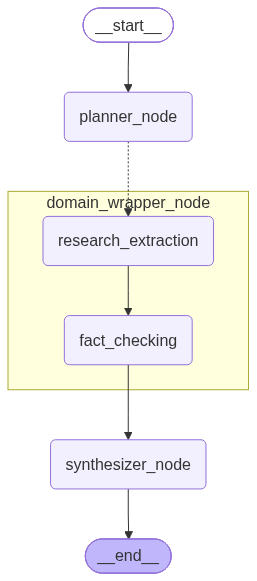

In [33]:
from langgraph.graph import StateGraph, START, END
from langgraph.constants import Send
from IPython.display import Image, display

# ==========================================
# 1. BUILD THE DOMAIN SUBGRAPH (Cleaned up)
# ==========================================
subgraph_builder = StateGraph(ResearchState)
subgraph_builder.add_node("research_extraction", researcher_node)
subgraph_builder.add_node("fact_checking", domain_fact_checker_node)

# Wire the Subgraph
subgraph_builder.add_edge(START, "research_extraction")
subgraph_builder.add_edge("research_extraction", "fact_checking")
subgraph_builder.add_edge("fact_checking", END)

domain_subgraph = subgraph_builder.compile()

# ==========================================
# 2. DEFINE THE PARALLEL ROUTER & WRAPPER
# ==========================================
def route_to_subgraphs(state: BaseeraState):
    """Routes the plan to our new wrapper node."""
    plan = state.get("research_plan", {})
    parallel_executions = []
    
    for domain, queries in plan.items():
        parallel_executions.append(Send("domain_wrapper_node", {
            "topic": domain, 
            "search_queries": queries,
            "raw_docs": [],
            "extracted_claims": [],
            "domain_verified_claims": []
        }))
        
    return parallel_executions

def domain_wrapper_node(state: dict):
    """
    Acts as the bridge. Runs the isolated subgraph, extracts its local verified 
    claims, and maps them to the exact key the Global State expects.
    """
    # 1. Run the subgraph synchronously
    result = domain_subgraph.invoke(state)
    
    # 2. Translate the local key to the global key
    return {"all_verified_claims": result.get("domain_verified_claims", [])}

# ==========================================
# 3. BUILD THE GLOBAL GRAPH (BASEERA)
# ==========================================
builder = StateGraph(BaseeraState)

builder.add_node("planner_node", planner_node)
builder.add_node("domain_wrapper_node", domain_wrapper_node)
builder.add_node("synthesizer_node", cross_domain_synthesizer_node)

builder.add_edge(START, "planner_node")
builder.add_conditional_edges("planner_node", route_to_subgraphs, ["domain_wrapper_node"])
builder.add_edge("domain_wrapper_node", "synthesizer_node")
builder.add_edge("synthesizer_node", END)

baseera_app = builder.compile()

print("Baseera System compiled successfully with Wrapper Node!")
display(Image(baseera_app.get_graph(xray=1).draw_mermaid_png()))

In [34]:
# Initialize the blank global state with our STC prompt
initial_state = {
    "company_name": "STC (Saudi Telecom Company)",
    "research_goal": "Assess their diversification strategy away from traditional telecom into digital services (fintech, cloud, IoT) to evaluate long-term revenue resilience."
}

print("🚀 Launching Baseera End-to-End Execution...\n")

# Stream the graph execution to watch the nodes fire in real-time
final_state_update = None
for event in baseera_app.stream(initial_state, stream_mode="updates"):
    for node_name, state_update in event.items():
        print(f"✅ Node Completed: {node_name}")
        final_state_update = state_update 

# The synthesizer is the final node, so its output contains the final analysis
print("\n" + "="*60)
print("🎯 FINAL EXECUTIVE SYNTHESIS")
print("="*60)

if final_state_update and "cross_domain_analysis" in final_state_update:
    print(final_state_update["cross_domain_analysis"])
else:
    print("Execution finished, but synthesis was not found in the final update.")

🚀 Launching Baseera End-to-End Execution...

🤖 Planner: Generating research strategy for STC (Saudi Telecom Company)...
✅ Node Completed: planner_node
🕵️‍♂️ Subgraph [Financial Performance Analysis]: Starting research...
   -> Searching: STC revenue breakdown by segment 2023
🕵️‍♂️ Subgraph [Market Position and Competitiveness]: Starting research...
   -> Searching: STC market share in fintech and cloud services 2023
🕵️‍♂️ Subgraph [Strategic Partnerships and Acquisitions]: Starting research...
   -> Searching: Recent acquisitions by STC in the digital services sector
🕵️‍♂️ Subgraph [Regulatory Environment and Challenges]: Starting research...
   -> Searching: Regulatory challenges facing STC in expanding digital services
   -> Searching: Impact of Saudi regulations on STC's fintech initiatives
   -> Searching: Partnerships STC has formed for fintech and cloud services
   -> Searching: Competitive analysis of STC's digital services against regional players
   -> Searching: STC financial

/Users/ranaalngashy/Documents/multimodal-osint-analyst/.venv/lib/python3.9/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=ExtractedClaimsList(claim...ic-partnerships.html')]), input_type=ExtractedClaimsList])
  return self.__pydantic_serializer__.to_python(


⚖️ Fact Checker [Strategic Partnerships and Acquisitions]: Verifying 4 claims...


/Users/ranaalngashy/Documents/multimodal-osint-analyst/.venv/lib/python3.9/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=ExtractedClaimsList(claim...files/saudi-telecom)')]), input_type=ExtractedClaimsList])
  return self.__pydantic_serializer__.to_python(


⚖️ Fact Checker [Financial Performance Analysis]: Verifying 4 claims...
⚖️ Fact Checker [Market Position and Competitiveness]: Verifying 4 claims...
🧠 Subgraph [Regulatory Environment and Challenges]: Extracting claims from raw text...


...

/Users/ranaalngashy/Documents/multimodal-osint-analyst/.venv/lib/python3.9/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=VerificationBatch(verific...upporting the claim.')]), input_type=VerificationBatch])
  return self.__pydantic_serializer__.to_python(


✅ Node Completed: domain_wrapper_node
✅ Node Completed: domain_wrapper_node


/Users/ranaalngashy/Documents/multimodal-osint-analyst/.venv/lib/python3.9/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=ExtractedClaimsList(claim...abia-telecom-market)')]), input_type=ExtractedClaimsList])
  return self.__pydantic_serializer__.to_python(


⚖️ Fact Checker [Regulatory Environment and Challenges]: Verifying 3 claims...
✅ Node Completed: domain_wrapper_node
🧩 Synthesizer: Analyzing 15 verified claims across domains...
✅ Node Completed: synthesizer_node

🎯 FINAL EXECUTIVE SYNTHESIS
The verified data regarding Saudi Telecom Company (stc) reveals a robust financial performance alongside a strategic pivot towards diversification into digital services. In FY2024, stc reported a revenue of approximately $75.89 billion and a net profit of $24.69 billion, marking an impressive 85.70% year-over-year increase. This financial strength provides a solid foundation for stc's ongoing transformation, as it expands its offerings beyond traditional telecommunications into areas such as fintech, cloud services, and IoT. The company's strategic initiatives, including partnerships with major players like AWS and acquisitions such as the 40% stake in Devoteam Middle East, underscore its commitment to enhancing its digital service portfolio and a

/Users/ranaalngashy/Documents/multimodal-osint-analyst/.venv/lib/python3.9/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=ExecutiveSynthesis(synthe...p in the coming years."), input_type=ExecutiveSynthesis])
  return self.__pydantic_serializer__.to_python(


In [35]:
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import MemorySaver

def human_review_node(state: BaseeraState) -> dict:
    """
    Pauses execution for a human to review the synthesis and provide steering feedback.
    """
    synthesis = state.get("cross_domain_analysis", "No synthesis generated.")
    
    print("\n⏸️ GRAPH PAUSED: Waiting for human review...")
    
    # The interrupt function suspends execution and saves state to the checkpointer
    feedback = interrupt({
        "message": "Please review the synthesis and provide feedback.",
        "synthesis": synthesis
    })
    
    print(f"👤 Human Feedback Received: {feedback}")
    return {"human_feedback": feedback}

def report_writer_node(state: BaseeraState) -> dict:
    """
    Generates the final executive report incorporating the human's feedback.
    """
    company = state.get("company_name", "")
    synthesis = state.get("cross_domain_analysis", "")
    feedback = state.get("human_feedback", "")
    
    print(f"📝 Report Writer: Drafting final report for {company}...")
    
    prompt = f"""
    You are an elite enterprise consultant finalizing a due diligence report for {company}.
    
    Here is the Cross-Domain Synthesis of our verified facts:
    {synthesis}
    
    Here is the specific steering feedback from the Lead Partner:
    {feedback}
    
    Write a highly professional, polished Final Report. Incorporate the human's feedback directly 
    into the strategic analysis. Use structured markdown, professional formatting, and objective language.
    """
    
    result = llm.invoke(prompt)
    return {"final_report": result.content}

In [36]:
# 1. Initialize an in-memory checkpointer to save state during pauses
memory = MemorySaver()

# 2. Build the Global Graph
builder = StateGraph(BaseeraState)

builder.add_node("planner_node", planner_node)
builder.add_node("domain_wrapper_node", domain_wrapper_node)
builder.add_node("synthesizer_node", cross_domain_synthesizer_node)
builder.add_node("human_review_node", human_review_node)
builder.add_node("report_writer_node", report_writer_node)

builder.add_edge(START, "planner_node")
builder.add_conditional_edges("planner_node", route_to_subgraphs, ["domain_wrapper_node"])
builder.add_edge("domain_wrapper_node", "synthesizer_node")
builder.add_edge("synthesizer_node", "human_review_node")
builder.add_edge("human_review_node", "report_writer_node")
builder.add_edge("report_writer_node", END)

# Compile with the checkpointer enabled
baseera_app = builder.compile(checkpointer=memory)

print("Baseera System compiled successfully with Human-in-the-Loop!")

Baseera System compiled successfully with Human-in-the-Loop!


In [38]:
# Define a unique thread to track this specific execution
thread_config = {"configurable": {"thread_id": "stc_diligence_1"}}

initial_state = {
    "company_name": "STC (Saudi Telecom Company)",
    "research_goal": "Assess their diversification strategy away from traditional telecom into digital services (fintech, cloud, IoT) to evaluate long-term revenue resilience."
}

print("🚀 Launching Baseera End-to-End Execution (Will pause for review)...\n")

# Part 1: Run until the interrupt is hit
for event in baseera_app.stream(initial_state, config=thread_config, stream_mode="updates"):
    for node_name, state_update in event.items():
        print(f"✅ Node Completed: {node_name}")

# Part 2: Resume the graph with Human Feedback
human_feedback = "Ensure the final report highlights STC's cloud investments as a critical hedge against telecom revenue saturation."
print(f"\n▶️ Resuming graph with feedback: {human_feedback}\n")

final_state_update = None
# We pass the feedback to the graph via the Command(resume=...) parameter
for event in baseera_app.stream(Command(resume=human_feedback), config=thread_config, stream_mode="updates"):
    for node_name, state_update in event.items():
        print(f"✅ Node Completed: {node_name}")
        final_state_update = state_update

print("\n" + "="*60)
print("🎯 FINAL DUE DILIGENCE REPORT")
print("="*60)

# The state_update is already the payload returned by the report writer
if final_state_update and "final_report" in final_state_update:
    print(final_state_update["final_report"])
else:
    print("Report data not found in the final state update.")

🚀 Launching Baseera End-to-End Execution (Will pause for review)...

🤖 Planner: Generating research strategy for STC (Saudi Telecom Company)...


/Users/ranaalngashy/Documents/multimodal-osint-analyst/.venv/lib/python3.9/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=ResearchPlan(plan=[Resear... services expansion"])]), input_type=ResearchPlan])
  return self.__pydantic_serializer__.to_python(


✅ Node Completed: planner_node
🕵️‍♂️ Subgraph [Market Analysis]: Starting research...
   -> Searching: STC market share in fintech services 2023
🕵️‍♂️ Subgraph [Regulatory Environment]: Starting research...
   -> Searching: regulatory challenges for telecom companies entering fintech in Saudi Arabia
🕵️‍♂️ Subgraph [Competitive Landscape]: Starting research...
   -> Searching: key competitors in the Saudi fintech market 2023
🕵️‍♂️ Subgraph [Financial Performance]: Starting research...
   -> Searching: STC revenue breakdown by segment 2023
   -> Searching: impact of Saudi Vision 2030 on telecom diversification strategies
   -> Searching: financial impact of STC's digital services diversification
   -> Searching: growth trends in cloud services for telecom companies in the Middle East
   -> Searching: analysis of STC's partnerships in cloud services
   -> Searching: compliance requirements for STC's digital services expansion
   -> Searching: benchmarking STC's IoT offerings against regio

/Users/ranaalngashy/Documents/multimodal-osint-analyst/.venv/lib/python3.9/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=ExtractedClaimsList(claim...tc-pay/default.aspx)')]), input_type=ExtractedClaimsList])
  return self.__pydantic_serializer__.to_python(
/Users/ranaalngashy/Documents/multimodal-osint-analyst/.venv/lib/python3.9/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=ExtractedClaimsList(claim...aa-5bedb4dd0138.pdf)')]), input_type=ExtractedClaimsList])
  return self.__pydantic_serializer__.to_python(


⚖️ Fact Checker [Competitive Landscape]: Verifying 4 claims...


...

✅ Node Completed: domain_wrapper_node


/Users/ranaalngashy/Documents/multimodal-osint-analyst/.venv/lib/python3.9/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=VerificationBatch(verific...nts and initiatives.')]), input_type=VerificationBatch])
  return self.__pydantic_serializer__.to_python(


✅ Node Completed: domain_wrapper_node
🧩 Synthesizer: Analyzing 31 verified claims across domains...


/Users/ranaalngashy/Documents/multimodal-osint-analyst/.venv/lib/python3.9/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=ExecutiveSynthesis(synthe...asingly digital world."), input_type=ExecutiveSynthesis])
  return self.__pydantic_serializer__.to_python(


✅ Node Completed: synthesizer_node

⏸️ GRAPH PAUSED: Waiting for human review...
✅ Node Completed: __interrupt__

▶️ Resuming graph with feedback: Ensure the final report highlights STC's cloud investments as a critical hedge against telecom revenue saturation.


⏸️ GRAPH PAUSED: Waiting for human review...
👤 Human Feedback Received: Ensure the final report highlights STC's cloud investments as a critical hedge against telecom revenue saturation.
✅ Node Completed: human_review_node
📝 Report Writer: Drafting final report for STC (Saudi Telecom Company)...
✅ Node Completed: report_writer_node

🎯 FINAL DUE DILIGENCE REPORT
# Final Due Diligence Report on Saudi Telecom Company (stc)

## Executive Summary

This report provides a comprehensive analysis of Saudi Telecom Company (stc), focusing on its strategic pivot from traditional telecommunications to a diversified portfolio that includes digital services such as fintech, cloud computing, and the Internet of Things (IoT). The findings unde